In [1]:
import torch
print(torch.__version__)


2.13.0+cu130


In [4]:
words = open("names.txt" ,"r").read().splitlines()
words[:10]

['aabad',
 'aaban',
 'aabdar',
 'aabid',
 'aabidah',
 'aabidullah',
 'aabir',
 'aabira',
 'aabirah',
 'aabis']

In [14]:

chars = sorted(list(set(''.join(words))))
stoi = {s : i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i : s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [19]:
n = torch.ones((27,27),dtype = torch.int32)
for w in words:
    s = "." + w + "."
    for ch1,ch2 in zip(s,s[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        n[ix1,ix2] += 1

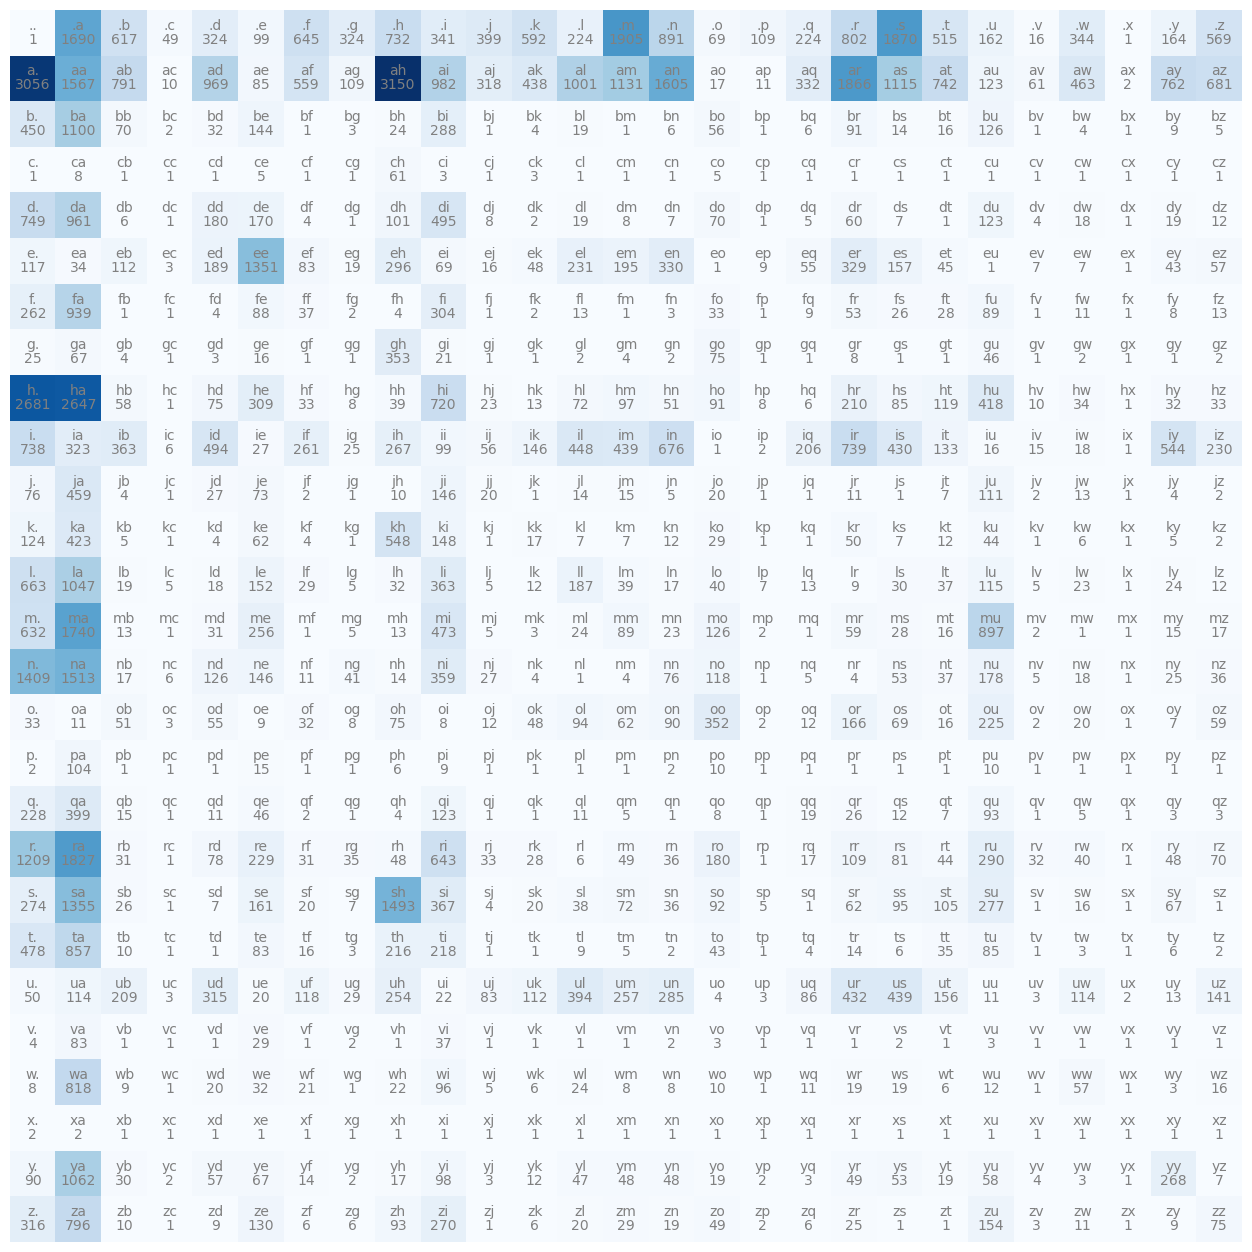

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(n, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, n[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [24]:
p = n.float()
d = p.sum(1 ,keepdim=  True )
P = p / d

In [25]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    out = []
    ix  = 0 
    while True :
        s = P[ix]
        ix = torch.multinomial(s, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

teeba.
moulaurailazitahamellimittain.
lufak.
kh.
aa.
samiyabbatahr.
gotas.
mizimalahujif.
teda.
ka.


In [27]:
neg_log_likelihood = 0.0
e = 0
for w in words:
    s = "." + w + "."
    for ch1,ch2 in zip(s,s[1:]):
        e+=1
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        log_prob = torch.log(prob) 
        neg_log_likelihood += log_prob
        
print(f'{neg_log_likelihood=}')
nll = -neg_log_likelihood
print(f'{nll=}')
print(f'{nll/e}')


neg_log_likelihood=tensor(-232839.6250)
nll=tensor(232839.6250)
2.3397440910339355
